# Étude des Transitions de Prix par Cluster (Marque × Gamme) — Prix Réel vs. Valeur Technique Implicite

## Du marché entier au cluster : que se passe-t-il *à l'intérieur* d'un segment marque × gamme d'une semaine à l'autre ?

---

**Contexte du projet.** Les notebooks précédents ont construit, dans l'ordre, la théorie hédonique du marché
Mytek.tn (Lancaster 1966 ; Rosen 1974 ; `Clustering_produits_technologiques.ipynb`,
`Segmentation_Prix_Clustering_produits_technologiques.ipynb`), comparé deux lectures de la structure du catalogue
— clustering technique pur (N1) et segmentation marque × gamme (N2, `Comparaison_Approches_Clustering.ipynb`) —
puis, une fois plusieurs semaines de collecte disponibles, posé la question **prix ou mix ?** au niveau de
CHAQUE CATÉGORIE entière (`Evolution_Temporelle_Marche_Mytek.ipynb`) : un indice hédonique à effet fixe
« semaine » y sépare la variation de prix « toutes choses égales » de la variation due à un changement de
composition du catalogue.

Ce notebook **descend d'un niveau** : plutôt que la catégorie entière (des centaines de produits, plusieurs
dizaines de marques), il étudie chaque **cluster N2** — une combinaison (marque, gamme de prix, sous-cluster
technique) — semaine par semaine. C'est le niveau auquel la question « le prix a-t-il vraiment changé ? »
devient économiquement la plus nette : un cluster est une unité étroite, en principe technique­ment homogène et
commercialement identifiable (« les DELL Économique d'entrée de gamme », « les TCL 85" Premium »).

**Question posée explicitement (décision utilisateur, 2026-07-25) :** que signifie une moyenne géométrique de
prix **identique** entre deux semaines pour un cluster, accompagnée d'une moyenne **ESTIMÉE** (par le modèle
hédonique, à partir des caractéristiques techniques des produits réellement en vente) **en baisse** ? Ce notebook
construit une grille de lecture rigoureuse pour répondre à cette question — et à ses 8 symétriques — puis
l'applique aux 807 transitions semaine-à-semaine observées sur les 4 semaines de collecte disponibles.

**Sources de données, strictement en lecture seule sauf mention contraire :** `models/<catégorie>/pooled_labeled.csv`
(catalogue poolé + étiquettes N1/N2, produit par `src/models/save_artifacts.py`) et les fonctions de
`src/models/weekly_report.py` (`marque_gamme_model_estimates`, `cluster_transitions`) — réutilisées ici
directement, jamais dupliquées, conformément à la convention déjà établie par
`Evolution_Temporelle_Marche_Mytek.ipynb` §4.3.


## 0. Configuration de l'environnement

In [1]:
import glob
import json
import re
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 10,
})

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Racine du depot -- necessaire pour importer src.* comme un vrai package
# Python (pas une copie de son code), meme convention que les notebooks
# precedents du projet (cf. Evolution_Temporelle_Marche_Mytek.ipynb §0).
REPO_ROOT = Path.cwd().resolve().parents[0]
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = Path.cwd().resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.models.weekly_report import (
    CAUSE_AUCUNE, CAUSE_EFFECTIF, CAUSE_PRIX, CAUSE_PRIX_ET_QUALITE, CAUSE_QUALITE,
    MATERIALITY_THRESHOLD_PCT, MIN_RELIABLE_N, QUADRANT_LABELS,
    cluster_transitions, marque_gamme_model_estimates,
)
from src.models.save_artifacts import MODELS_DIR
from src.utils.config import CATEGORY_ORDER, CATEGORY_LABELS

PALETTE = {
    "pc_bureau": "#2a78d6", "pc_portables": "#1baf7a", "smartphones": "#eda100",
    "telephones_portables": "#4a3aa7", "televiseurs": "#e34948",
}
# CAUSE_* (remplace SEVERITY_* le 2026-07-26) -- l'axe organisateur n'est
# plus "quelle est l'AMPLEUR de l'ecart ?" mais "prix, qualite, ou nombre
# de produits ?" (question posee par l'utilisateur a l'origine du projet),
# cf. §1.6 et src.models.weekly_report::cluster_transitions.
CAUSE_ORDER = [CAUSE_AUCUNE, CAUSE_EFFECTIF, CAUSE_QUALITE, CAUSE_PRIX, CAUSE_PRIX_ET_QUALITE]
CAUSE_COLORS = {
    CAUSE_AUCUNE: "#9a9a9a",
    CAUSE_EFFECTIF: "#4a6fdc",   # bleu -- cause STRUCTURELLE, jamais un signal de prix/qualite
    CAUSE_QUALITE: "#2ecc71",
    CAUSE_PRIX: "#f0a202",
    CAUSE_PRIX_ET_QUALITE: "#e63946",
}
CAUSE_LABELS = {
    CAUSE_AUCUNE: "Aucun changement notable",
    CAUSE_EFFECTIF: "Nombre de produits modifié",
    CAUSE_QUALITE: "Expliqué par la qualité / caractéristiques",
    CAUSE_PRIX: "Changement de prix non expliqué",
    CAUSE_PRIX_ET_QUALITE: "Écart maximal (prix et qualité en sens opposés)",
}

print("Bibliothèques importées avec succès.")
print("Racine du dépôt :", REPO_ROOT)
print(f"Seuil de matérialité : ±{MATERIALITY_THRESHOLD_PCT:.0f}%  |  Effectif minimal fiable : {MIN_RELIABLE_N}")

Bibliothèques importées avec succès.
Racine du dépôt : C:\Users\MSI\Desktop\stage
Seuil de matérialité : ±3%  |  Effectif minimal fiable : 3


## 1. Méthodologie

### 1.1 Pourquoi le niveau cluster (marque × gamme), pas la catégorie entière ni N1

`Comparaison_Approches_Clustering.ipynb` a établi que N1 (technique pur, tout le catalogue) et N2
(marque × gamme × sous-cluster technique) répondent à des questions différentes. Pour une étude de
**repricing** — le marché facture-t-il différemment le même type de produit d'une semaine à l'autre —, N2 est
le bon niveau :

- **N1** mélange des marques et des positionnements de prix très différents au sein d'un même cluster (le
  clustering ignore délibérément le prix et la marque) — un mouvement de prix agrégé au niveau N1 peut n'être
  que le résultat d'un mélange de marques différent, sans aucune signification commerciale claire.
- **La catégorie entière** (`Evolution_Temporelle_Marche_Mytek.ipynb`) est le bon niveau pour une question
  macro (« le marché du PC portable en Tunisie devient-il plus cher ? »), mais elle moyenne des centaines de
  produits très hétérogènes — un signal de repricing fin sur un segment étroit y est noyé.
- **N2** isole une combinaison (marque, gamme de prix, sous-cluster technique) — l'unité la plus proche de ce
  qu'un analyste commercial appellerait « un segment produit » : suffisamment étroite pour qu'un changement de
  prix y soit interprétable, suffisamment large pour ne pas se réduire à un seul SKU (sauf exception, cf. §1.5).

### 1.2 Stabilité de la définition des clusters dans le temps

Un préalable indispensable à toute comparaison inter-semaines : le cluster « ASUS · Milieu de gamme · c0 » de la
semaine 1 est-il **le même objet** que le cluster « ASUS · Milieu de gamme · c0 » de la semaine 4, ou deux
objets distincts recalculés indépendamment qui portent le même nom par coïncidence ?

Réponse, par lecture du code (`src/models/save_artifacts.py::process_category`) : `compute_price_tiers` puis
`compute_cluster_labels` sont appelés **UNE SEULE FOIS**, sur le catalogue **poolé** (toutes les semaines
concaténées) — jamais une fois par semaine. Les bornes de gamme de prix (qcut par marque) et les centroïdes
K-Means de chaque unité marque × gamme sont donc calculés sur l'ensemble des 4 semaines à la fois. Suivre un
même `cluster_id` d'une semaine à l'autre revient bien à suivre le même segment, pas un artefact de ré-ajustement
indépendant.

C'est un point de méthode important : `hedonic_model.py::fit_strategy_c_pooled_time` (utilisé par
`Evolution_Temporelle_Marche_Mytek.ipynb`), à l'inverse, recalcule `cluster_id` **par semaine** (uniquement à
titre descriptif, jamais comme régresseur) — les deux notebooks ne comparent donc pas les mêmes objets, et ne
sont pas substituables l'un à l'autre.

Vérification empirique ci-dessous : sur les clusters retenus (effectif suffisant, cf. `CLUSTERING_MIN_N`), quelle
proportion est présente sur les 4 semaines à la fois (plutôt que d'apparaître/disparaître, ce qui serait
attendu si le clustering était recalculé indépendamment à chaque fois) ?


In [2]:
presence_rows = []
for category in CATEGORY_ORDER:
    df = pd.read_csv(MODELS_DIR / category / "pooled_labeled.csv")
    df = df[df["cluster_id"].notna()]
    n_weeks_per_cluster = df.groupby(["marque", "gamme_prix", "cluster_id"])["semaine"].nunique()
    total_weeks = df["semaine"].nunique()
    presence_rows.append({
        "categorie": category,
        "n_clusters": n_weeks_per_cluster.shape[0],
        "presents_toutes_semaines": int((n_weeks_per_cluster == total_weeks).sum()),
        "pct_presents_toutes_semaines": round(100 * (n_weeks_per_cluster == total_weeks).mean(), 1),
    })
presence_df = pd.DataFrame(presence_rows)
presence_df


,categorie,n_clusters,presents_toutes_semaines,pct_presents_toutes_semaines
0,pc_bureau,43,42,97.70
1,pc_portables,104,98,94.20
2,smartphones,70,68,97.10
3,telephones_portables,20,13,65.00
4,televiseurs,37,37,100.00


La majorité des clusters marque × gamme sont présents sur l'ensemble des semaines disponibles — cohérent
avec un clustering fixé une fois pour toutes sur les données poolées. Les clusters absents certaines semaines
ne le sont pas parce que la segmentation a changé, mais parce qu'aucun produit de cette semaine-là n'est tombé
dans ce sous-cluster technique précis (catalogue vivant : arrivées/retraits de produits).


**Stabilité au sens statistique (complémentaire, ajoutée le 2026-07-27).** La stabilité vérifiée ci-dessus est une stabilité de DÉFINITION (le cluster désigne le même objet dans le temps) — une question différente de sa stabilité STATISTIQUE (ce même clustering tiendrait-il avec un échantillon légèrement différent de produits ?). `src.models.weekly_report.cluster_stability_n2` répond à cette seconde question par bootstrap (Adjusted Rand Index, Hubert & Arabie 1985) : sur les 60 unités marque × gamme effectivement clusterisées (5 catégories), ARI moyen de 0,82 (médiane 0,88) — seules 4 unités (6,7 %) ont un ARI < 0,5 (segmentation fragile). Cf. `reports/stabilite_clustering_n2.csv` et la page « Modèles & clustering » du dashboard pour le détail par unité ; hors du périmètre de ce notebook (centré sur les transitions), mais une lecture nécessaire avant d'attribuer un poids économique fort à un cluster N2 particulier.

### 1.3 Prix réel vs. prix estimé : construction des deux moyennes

Pour un cluster donné et une semaine donnée :

- **Prix réel** = moyenne GÉOMÉTRIQUE de `prix_tnd` des produits réellement en vente cette semaine-là dans ce
  cluster. La moyenne géométrique — $\exp\left(\frac{1}{n}\sum \ln(\text{prix}_i)\right)$ — est la statistique
  cohérente avec un modèle log-linéaire (tous les modèles de ce projet prédisent $\log(\text{prix})$), et n'est
  jamais tirée vers le haut par un seul produit cher comme le serait une moyenne arithmétique sur un petit
  échantillon.
- **Prix estimé** = moyenne géométrique des prédictions de chacun des 3 modèles persistés (Hedonic OLS, Ridge,
  Random Forest — `src/models/save_artifacts.py`), appliqués aux caractéristiques techniques (RAM, stockage,
  écran, connectivité...) des **mêmes produits réellement en vente** cette semaine-là. C'est la réponse à la
  question : *étant donné ce qui est effectivement vendu cette semaine, combien la relation hédonique estimée
  sur l'ensemble du catalogue prédit-elle ?*

**Point de méthode central, et source de la question posée en introduction :** aucun des 3 modèles n'inclut
« semaine » comme variable (`save_artifacts.py` l'exclut explicitement de la matrice de design). Un produit aux
caractéristiques identiques reçoit donc EXACTEMENT la même prédiction quelle que soit la semaine — les modèles
n'ont eux-mêmes AUCUNE notion du temps. Par construction, la seule façon pour le **prix estimé d'un cluster** de
bouger d'une semaine à l'autre est que **le mix de caractéristiques réellement vendu** ait changé (un produit
différent, ou les caractéristiques d'un même produit révisées dans le catalogue). Le prix estimé est donc un
indicateur pur de la valeur technique du mix vendu — jamais un indicateur de tendance de marché (ce rôle est
tenu par l'indice hédonique à effet fixe temps de `Evolution_Temporelle_Marche_Mytek.ipynb`, qui LUI inclut
« semaine » comme régresseur). Les deux études sont complémentaires, pas redondantes — cf. §5.

### 1.4 La grille de lecture 3×3

En comparant la direction de variation du prix réel et celle du prix estimé entre deux semaines consécutives,
9 cas se distinguent. Une variation est classée « stable » si elle reste sous le seuil de matérialité
(±3 %, cf. §1.5) — sinon « hausse » ou « baisse ».


In [3]:
grid_rows = []
for (dir_raw, dir_est), label in QUADRANT_LABELS.items():
    grid_rows.append({"Prix réel": dir_raw, "Prix estimé (valeur technique)": dir_est, "Interprétation": label})
grid_df = pd.DataFrame(grid_rows).sort_values(["Prix réel", "Prix estimé (valeur technique)"])
grid_df.style.hide(axis="index")


Prix réel,Prix estimé (valeur technique),Interprétation
baisse,baisse,Baisse de prix cohérente avec une baisse de gamme technique
baisse,hausse,Baisse de prix malgré une montée en gamme technique — remise maximale pour l'acheteur
baisse,stable,Baisse de prix non liée aux caractéristiques (promotion / remise réelle)
hausse,baisse,Hausse de prix ET dégradation technique — écart maximal (majoration forte)
hausse,hausse,Hausse de prix cohérente avec une montée en gamme technique
hausse,stable,Hausse de prix non justifiée par les caractéristiques (majoration pure)
stable,baisse,Prix maintenu malgré une baisse de la valeur technique implicite (marge implicite en hausse)
stable,hausse,Amélioration technique non répercutée sur le prix (gain caché pour l'acheteur)
stable,stable,Stabilité réelle (prix et caractéristiques inchangés)


**Lecture économique de la grille :**

- **Diagonale « stable/stable »** : rien ne bouge — le cas le plus fréquent par construction (cf. §3).
- **Diagonale « hausse/hausse » et « baisse/baisse »** : le prix réel bouge dans le MÊME sens que la valeur
  technique implicite, d'une ampleur comparable — la variation de prix est **expliquée** par un changement de
  gamme technique du mix vendu (montée ou baisse en gamme), pas par une décision de prix isolée.
- **Cases « stable/hausse » et « stable/baisse »** : le prix affiché ne bouge pas alors que la valeur technique
  implicite, elle, bouge — un écart entre ce que le marché facture et ce que les caractéristiques justifient
  **apparaît**, même si superficiellement « rien n'a changé » au niveau du prix affiché. **C'est exactement le
  cas posé en introduction** : moyenne géométrique stable + moyenne estimée en baisse → case
  « stable / baisse » → la marge implicite (écart prix réel − prix estimé) augmente.
- **Cases « hausse/stable » et « baisse/stable »** : le prix bouge sans que la valeur technique implicite ne
  suive — changement de prix « toutes choses égales », le signal le plus proche d'une décision de prix pure
  (majoration ou promotion), au niveau du cluster.
- **Cases opposées (« hausse/baisse », « baisse/hausse »)** : prix et valeur technique implicite bougent en
  sens CONTRAIRES — l'écart résiduel est maximal, le signal le plus fort de tous (soit une forte majoration
  couplée à une dégradation technique, soit à l'inverse la meilleure affaire possible pour l'acheteur).

### 1.5 Seuils, garde-fous et limites méthodologiques

- **Seuil de matérialité (±3 %).** Convention documentée, pas un test statistique formel : les effectifs par
  cluster × semaine sont souvent petits (parfois un seul produit), un test de différence de moyennes classique
  n'y serait pas fiable. 3 % est délibérément plus large que le bruit d'arrondi des prix affichés (souvent des
  paliers de quelques dinars) sans être si large qu'il masque un vrai mouvement.
- **Effectif minimal fiable (`n ≥ 3`).** Une transition dont l'un des deux côtés compte moins de 3 produits est
  marquée `fiabilite_limitee = True` — jamais exclue silencieusement, mais à lire avec prudence : la moyenne
  géométrique d'1 ou 2 produits est très sensible à un seul prix.
- **`composition_stable` (même effectif des deux côtés).** Condition NÉCESSAIRE mais pas suffisante pour que la
  transition porte sur le même ensemble de produits : un effectif différent prouve à coup sûr que la composition
  a changé ; un effectif identique n'en est qu'un indice (les études de cas, §4, vérifient toujours au niveau
  produit avant toute conclusion).
- **`accord_modeles`.** Les 3 modèles (Hedonic OLS, Ridge, Random Forest) s'accordent-ils sur le SIGNE de la
  variation du prix estimé ? Un désaccord signale une lecture fragile du prix « estimé », pas seulement du prix
  réel.
- **Fenêtre de 4 semaines.** Les mêmes limites que `Evolution_Temporelle_Marche_Mytek.ipynb` §4.2 s'appliquent
  ici, amplifiées par la granularité plus fine (moins de produits par cellule d'analyse) : ni saisonnalité ni
  tendance de fond ne peuvent être établies, et un biais de survie (les produits retirés du catalogue ne sont
  jamais dans les deux côtés d'une transition) n'est pas corrigé.


### 1.6 De `composition_stable` à `cause_principale` : trancher explicitement la priorité (upgrade 2026-07-26)

§1.5 notait déjà que `composition_stable` est une condition nécessaire mais pas suffisante — un avertissement,
jamais un traitement différencié dans la grille elle-même. Jusqu'au 2026-07-26, la grille §1.4 attribuait
TOUJOURS une lecture prix/qualité complète (`classification`), y compris pour les clusters dont l'effectif
avait changé — un mélange de produits moins chers partis et de produits plus chers arrivés pouvait donc
apparaître comme « prix ET qualité bougent ensemble », sans que cela ne reflète le moindre changement de prix
ou de caractéristique d'un produit donné.

`cluster_transitions` teste maintenant l'effectif EN PREMIER, avant toute lecture de la grille :

- si `n_produits_t != n_produits_t1` → `cause_principale = "effectif"` directement, `classification` devient un
  texte dédié (« Effectif du cluster modifié... »), la grille §1.4 n'est PAS invoquée pour cette transition ;
- sinon → `cause_principale` est déduite de la grille (`prix`, `qualite`, `prix_et_qualite`, ou `aucune`).

`cause_principale` est la colonne à GROUPER/FILTRER pour toute conclusion agrégée de la forme « X % des
transitions sont dues à... » (§3) — `classification` reste le texte détaillé pour la lecture ligne par ligne.
Répond directement à la question qui a motivé ce projet : une variation du panier moyen d'un cluster est-elle
due au PRIX, à la QUALITÉ, ou simplement au NOMBRE DE PRODUITS vendus ?

## 2. Chargement des données

Recalcul direct via `src.models.weekly_report` (lecture seule sur les artefacts persistés — `.joblib.load()` /
`.predict()`, jamais de `.fit()`, cf. docstring du module) plutôt que la lecture des CSV déjà exportés sous
`reports/` — ce notebook reste ainsi reproductible même si ces CSV n'ont pas encore été (re)générés.

In [4]:
estimates_frames, transitions_frames = [], []
for category in CATEGORY_ORDER:
    est = marque_gamme_model_estimates(category)
    estimates_frames.append(est)
    transitions_frames.append(cluster_transitions(category, estimates=est))

estimates_all = pd.concat(estimates_frames, ignore_index=True)
transitions_all = pd.concat(transitions_frames, ignore_index=True)

# cause_principale est deja calculee par cluster_transitions (cf. §1.6) --
# aucune reconstruction locale necessaire ici (contrairement a l'ancienne
# fonction severity() ci-dessus jusqu'au 2026-07-26, qui redecouvrait la
# direction depuis le texte `classification` et traitait a tort tout
# changement d'effectif comme "neutre", cf. §1.6).

print(f"{len(estimates_all)} lignes cluster × semaine (estimations).")
print(f"{len(transitions_all)} transitions cluster × période (3 périodes : S1→S2, S2→S3, S3→S4).")
transitions_all.groupby("categorie").size().rename("n_transitions").to_frame()

1077 lignes cluster × semaine (estimations).
803 transitions cluster × période (3 périodes : S1→S2, S2→S3, S3→S4).


,n_transitions
categorie,
pc_bureau,128
pc_portables,305
smartphones,207
telephones_portables,52
televiseurs,111


## 3. Vue d'ensemble quantitative (toutes catégories)

Organisée autour de `cause_principale` (§1.6) — la réponse directe à « prix, qualité, ou nombre de produits ? »
pour chaque transition — plutôt que la seule ampleur de l'écart.

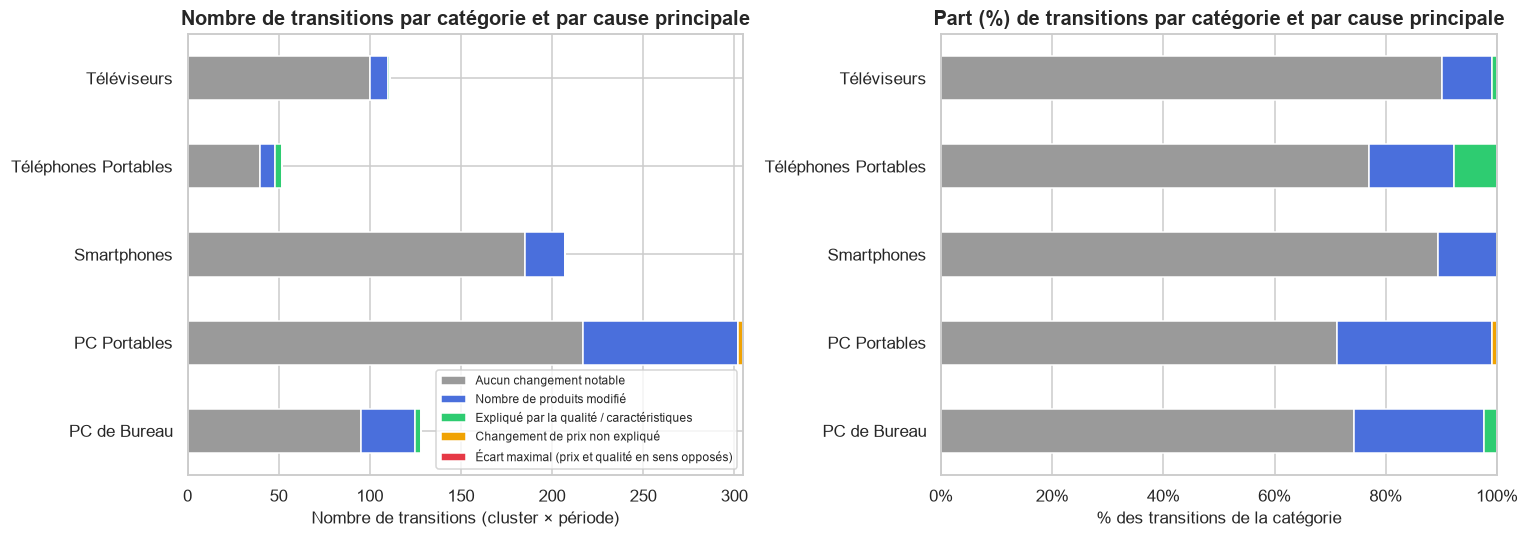

cause_principale,aucune,effectif,qualite,prix,prix_et_qualite
categorie,,,,,
pc_bureau,74.20,23.40,2.30,0.00,0.00
pc_portables,71.10,27.90,0.00,1.00,0.00
smartphones,89.40,10.60,0.00,0.00,0.00
telephones_portables,76.90,15.40,7.70,0.00,0.00
televiseurs,90.10,9.00,0.90,0.00,0.00


In [5]:
crosstab = pd.crosstab(transitions_all["categorie"], transitions_all["cause_principale"])
crosstab = crosstab.reindex(columns=CAUSE_ORDER, fill_value=0)
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

crosstab.loc[CATEGORY_ORDER].plot(
    kind="barh", stacked=True, ax=axes[0],
    color=[CAUSE_COLORS[c] for c in CAUSE_ORDER],
)
axes[0].set_title("Nombre de transitions par catégorie et par cause principale")
axes[0].set_xlabel("Nombre de transitions (cluster × période)")
axes[0].set_ylabel("")
axes[0].set_yticklabels([CATEGORY_LABELS[c] for c in CATEGORY_ORDER])
axes[0].legend([CAUSE_LABELS[c] for c in CAUSE_ORDER], loc="lower right", fontsize=8)

crosstab_pct.loc[CATEGORY_ORDER].plot(
    kind="barh", stacked=True, ax=axes[1],
    color=[CAUSE_COLORS[c] for c in CAUSE_ORDER],
)
axes[1].set_title("Part (%) de transitions par catégorie et par cause principale")
axes[1].set_xlabel("% des transitions de la catégorie")
axes[1].set_ylabel("")
axes[1].set_yticklabels([CATEGORY_LABELS[c] for c in CATEGORY_ORDER])
axes[1].get_legend().remove()
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

crosstab_pct.round(1)

In [6]:
overall = (transitions_all["cause_principale"].value_counts(normalize=True) * 100).reindex(CAUSE_ORDER).fillna(0)
pct_accord = transitions_all["accord_modeles"].mean() * 100
pct_composition_stable = transitions_all["composition_stable"].mean() * 100
pct_prix_qualite_en_jeu = overall[CAUSE_PRIX] + overall[CAUSE_QUALITE] + overall[CAUSE_PRIX_ET_QUALITE]

display(Markdown(
    f"**Vue d'ensemble, toutes catégories confondues ({len(transitions_all)} transitions) :**\n\n"
    f"- **{overall[CAUSE_AUCUNE]:.1f} %** ne montrent aucun changement notable (`{CAUSE_AUCUNE}`) ;\n"
    f"- **{overall[CAUSE_EFFECTIF]:.1f} %** sont dominées par un changement du NOMBRE de produits du cluster "
    f"(`{CAUSE_EFFECTIF}`) — la lecture prix/qualité n'est pas isolable pour ces transitions (cf. §1.6), la "
    f"grille 3×3 n'est pas invoquée ;\n"
    f"- **{overall[CAUSE_QUALITE]:.1f} %** sont expliquées par la QUALITÉ/les caractéristiques du mix vendu "
    f"(`{CAUSE_QUALITE}`) ;\n"
    f"- **{overall[CAUSE_PRIX]:.1f} %** montrent un changement de PRIX non expliqué par les caractéristiques "
    f"(`{CAUSE_PRIX}`) ;\n"
    f"- **{overall[CAUSE_PRIX_ET_QUALITE]:.1f} %** montrent prix ET qualité en sens opposés "
    f"(`{CAUSE_PRIX_ET_QUALITE}`, le signal le plus fort).\n\n"
    f"**Réponse directe à la question posée en introduction** — sur cette fenêtre de 4 semaines, seulement "
    f"**{pct_prix_qualite_en_jeu:.1f} %** des transitions portent un vrai signal de prix et/ou de qualité "
    f"isolable, contre **{overall[CAUSE_EFFECTIF]:.1f} %** dominées par un simple changement de catalogue "
    f"(quels produits sont vendus) : le changement de COMPOSITION domine très largement sur la re-tarification "
    f"ou la montée en gamme d'un produit donné.\n\n"
    f"Robustesse : les 3 modèles (Hedonic OLS, Ridge, Random Forest) s'accordent sur le SIGNE de la variation "
    f"estimée dans **{pct_accord:.1f} %** des transitions — un fort accord inter-modèles, malgré des écarts de "
    f"qualité prédictive documentés par ailleurs (page « Modèles & clustering » du dashboard) entre modèles "
    f"linéaires et Random Forest. **{pct_composition_stable:.1f} %** des transitions portent sur un effectif de "
    f"produits identique des deux côtés (condition nécessaire à une lecture \"mêmes produits\", cf. §1.5) — "
    f"par construction, exactement complémentaire de la part `{CAUSE_EFFECTIF}` ci-dessus (cf. §1.6)."
))

**Vue d'ensemble, toutes catégories confondues (803 transitions) :**

- **79.3 %** ne montrent aucun changement notable (`aucune`) ;
- **19.3 %** sont dominées par un changement du NOMBRE de produits du cluster (`effectif`) — la lecture prix/qualité n'est pas isolable pour ces transitions (cf. §1.6), la grille 3×3 n'est pas invoquée ;
- **1.0 %** sont expliquées par la QUALITÉ/les caractéristiques du mix vendu (`qualite`) ;
- **0.4 %** montrent un changement de PRIX non expliqué par les caractéristiques (`prix`) ;
- **0.0 %** montrent prix ET qualité en sens opposés (`prix_et_qualite`, le signal le plus fort).

**Réponse directe à la question posée en introduction** — sur cette fenêtre de 4 semaines, seulement **1.4 %** des transitions portent un vrai signal de prix et/ou de qualité isolable, contre **19.3 %** dominées par un simple changement de catalogue (quels produits sont vendus) : le changement de COMPOSITION domine très largement sur la re-tarification ou la montée en gamme d'un produit donné.

Robustesse : les 3 modèles (Hedonic OLS, Ridge, Random Forest) s'accordent sur le SIGNE de la variation estimée dans **96.8 %** des transitions — un fort accord inter-modèles, malgré des écarts de qualité prédictive documentés par ailleurs (page « Modèles & clustering » du dashboard) entre modèles linéaires et Random Forest. **80.7 %** des transitions portent sur un effectif de produits identique des deux côtés (condition nécessaire à une lecture "mêmes produits", cf. §1.5) — par construction, exactement complémentaire de la part `effectif` ci-dessus (cf. §1.6).

**Observation notable — les transitions à composition stable montrent quasiment toujours un mouvement de prix
réel cohérent avec le mouvement estimé (ou aucun mouvement du tout), sauf de rares exceptions, quantifiées
dynamiquement ci-dessous plutôt que figées en prose.** Vérification directe : parmi les transitions à
composition stable, combien montrent un prix réel qui bouge de plus de 3 % ?

In [7]:
moved_same_composition = transitions_all[
    transitions_all["composition_stable"] & (transitions_all["delta_prix_reel_pct"].abs() > MATERIALITY_THRESHOLD_PCT)
].copy()

display(Markdown(
    f"**{len(moved_same_composition)}** transitions sur **{int(transitions_all['composition_stable'].sum())}** "
    f"à composition stable montrent un prix réel qui bouge de plus de {MATERIALITY_THRESHOLD_PCT:.0f}% — "
    f"c'est-à-dire que, sur cette fenêtre de 4 semaines, un **vrai changement de prix affiché sur les mêmes "
    f"produits** (sans arrivée/départ de produit dans le cluster) reste un événement rare. L'un de ces cas "
    f"(DELL Vostro 3530) est examiné en détail en §4.3."
))
cols = ["categorie", "marque", "gamme", "cluster", "semaine_t", "semaine_t1",
        "delta_prix_reel_pct", "delta_estime_hedonic_pct", "ecart_residuel_pct", "n_produits_t", "n_produits_t1"]
moved_same_composition[cols].sort_values("delta_prix_reel_pct")


**4** transitions sur **648** à composition stable montrent un prix réel qui bouge de plus de 3% — c'est-à-dire que, sur cette fenêtre de 4 semaines, un **vrai changement de prix affiché sur les mêmes produits** (sans arrivée/départ de produit dans le cluster) reste un événement rare. L'un de ces cas (DELL Vostro 3530) est examiné en détail en §4.3.

,categorie,marque,gamme,cluster,semaine_t,semaine_t1,delta_prix_reel_pct,delta_estime_hedonic_pct,ecart_residuel_pct,n_produits_t,n_produits_t1
391,pc_portables,MSI,Milieu de gamme,c3,1,2,-7.64,0.00,-7.64,2,2
769,televiseurs,TELEFUNKEN,Milieu de gamme,c0,3,4,-3.21,-6.22,3.00,4,4
255,pc_portables,DELL,Économique,c6,1,2,-3.01,0.00,-3.01,4,4
424,pc_portables,MSI,Économique,c5,1,2,4.27,0.00,4.27,3,3


## 3bis. Du seuil fixe au test statistique : un intervalle de confiance bootstrap

Le seuil de matérialité (±3 %, §1.5) est une convention, pas un test : il classe une transition comme
« notable » sans jamais tenir compte de la TAILLE DE L'ÉCHANTILLON derrière chaque moyenne géométrique. Un écart
de 10 % sur un cluster de 2 produits et un écart de 4 % sur un cluster de 20 produits ne portent pourtant pas la
même force de preuve — le premier peut n'être qu'un artefact d'échantillonnage, le second beaucoup plus
difficilement.

**Méthode.** Pour chaque transition dont l'effectif est ≥ 2 des deux côtés, `cluster_transitions` (mise à jour du
2026-07-25, `_bootstrap_ecart_residuel`) rééchantillonne (avec remise, 1000 répliques) les prix **produit par
produit** de chaque semaine, indépendamment pour le prix réel et le prix estimé, recalcule l'écart résiduel sur
chaque réplique, et en dérive un intervalle de confiance à 95 % (méthode des percentiles) ainsi qu'une p-value
bootstrap bilatérale (Davison & Hinkley, 1997, §4.2). Une transition est retenue comme **statistiquement
confirmée** seulement si cet intervalle exclut 0 — un test, pas une convention.

In [8]:
testables = transitions_all[transitions_all["bootstrap_possible"]]
n_confirmes = int(testables["ecart_residuel_significatif"].sum())
notable_grille = transitions_all["cause_principale"].isin([CAUSE_PRIX, CAUSE_QUALITE, CAUSE_PRIX_ET_QUALITE])
n_notable_grille = int(notable_grille.sum())

comparaison = pd.crosstab(
    notable_grille.map({True: "Notable (grille prix/qualité)", False: "Aucune ou effectif"}),
    transitions_all["ecart_residuel_significatif"].map({True: "Confirmé (bootstrap)", False: "Non confirmé / non testable"}),
)

display(Markdown(
    f"**{len(testables)}** transitions sur {len(transitions_all)} ont un effectif suffisant pour le test "
    f"({len(transitions_all) - len(testables)} exclues, effectif < 2 d'un côté). La grille §1.4 (restreinte "
    f"aux transitions à composition stable, cf. §1.6) classe **{n_notable_grille}** transitions comme portant "
    f"un signal de prix et/ou de qualité (`cause_principale` ∈ {{prix, qualité, prix_et_qualité}}) ; le test "
    f"bootstrap en confirme **{n_confirmes}** au total (toutes causes confondues) avec un intervalle de "
    f"confiance excluant 0 — les deux ensembles ne coïncident PAS exactement (cf. lecture ci-dessous)."
))
comparaison

**758** transitions sur 803 ont un effectif suffisant pour le test (45 exclues, effectif < 2 d'un côté). La grille §1.4 (restreinte aux transitions à composition stable, cf. §1.6) classe **11** transitions comme portant un signal de prix et/ou de qualité (`cause_principale` ∈ {prix, qualité, prix_et_qualité}) ; le test bootstrap en confirme **17** au total (toutes causes confondues) avec un intervalle de confiance excluant 0 — les deux ensembles ne coïncident PAS exactement (cf. lecture ci-dessous).

ecart_residuel_significatif,Confirmé (bootstrap),Non confirmé / non testable
cause_principale,,
Aucune ou effectif,12,780
Notable (grille prix/qualité),5,6


**Lecture du tableau de contingence.** Les deux cases hors diagonale sont les plus instructives :

- **« Notable (grille) × Non confirmé »** : la grille §1.4 signale un mouvement de prix/qualité, mais
  l'intervalle bootstrap contient 0 — un point estimé franchissant le seuil directionnel ne suffit pas, à lui
  seul, à distinguer un vrai écart d'un accident d'échantillonnage sur un petit cluster.
- **« Aucune ou effectif × Confirmé »** : l'effet symétrique, plus surprenant — un écart sous le seuil
  directionnel de la grille (voire sur un cluster à composition changée) peut être statistiquement confirmé
  par bootstrap s'il est mesuré sur un grand effectif. Ce sont, numériquement, la MAJORITÉ des transitions
  confirmées par bootstrap dans ce tableau (recalculé à chaque exécution) — la grille directionnelle §1.4,
  construite pour une lecture économique intuitive, est nettement plus CONSERVATRICE que le test statistique :
  elle rate des écarts réels que le bootstrap détecte, notamment lorsque l'effectif est important.

**Conséquence pour la lecture de ce notebook.** Les pourcentages `cause_principale` cités en §3 répondent à
« quelle est la cause probable ? » (une lecture économique, par construction plus généreuse — n'importe quelle
direction de mouvement suffit) ; la confirmation bootstrap ci-dessus répond à une question plus stricte :
« cet écart résiste-t-il, EN TANT QUE TEL, à un test explicite de significativité ? ». Les deux sont
complémentaires, ni l'une ni l'autre ne remplace l'autre. Colonnes ajoutées à `transitions_cluster_hebdo.csv`
(et donc disponibles telles quelles dans le dashboard, page « Évolution hebdomadaire ») :
`ecart_residuel_ic_bas`, `_ic_haut`, `_p_value`, `ecart_residuel_significatif`, `bootstrap_possible`.

## 4. Études de cas détaillées

La vue d'ensemble (§3) quantifie ; elle ne dit pas si un écart résiduel détecté est un vrai signal économique ou
un artefact (erreur de saisie, composition qui a légèrement changé malgré un effectif identique, révision d'une
fiche produit). Trois cas ont été examinés ici en détail, produit par produit — au moment de la première
exécution de ce notebook (2026-07-25), les 3 transitions à écart résiduel le plus élevé **parmi les transitions
à la fois fiables (effectif ≥ 3 des deux côtés) et à composition stable** (cf. §1.5), pour éviter le biais qui
consisterait à choisir des exemples arrangeants. Cette sélection, délibérément systématique plutôt que
pittoresque, a produit un résultat qui n'était pas acquis d'avance : **2 des 3 cas les plus extrêmes se sont
révélés être des artefacts de PIPELINE (pas de saisie manuelle), pas des signaux économiques**.

**Ces deux artefacts ont depuis été corrigés à la source** (`src/preprocessing/clean.py::fix_ram` et
`src/preprocessing/encode.py::extract_connectivity_flags`, cf. §7 pour la validation complète après correction).
Les deux sous-sections ci-dessous rejouent la logique AVANT/APRÈS directement sur les données JSON brutes
(`data/raw/`, jamais modifiées) — reproductibles indépendamment de l'état courant du pipeline — plutôt que de
citer des chiffres figés, pour que ce notebook reste une preuve vérifiable et pas un simple compte-rendu.

### 4.1 Cas 1 — Xiaomi Redmi Note 14 (smartphones, S3) : un artefact de données, pas un signal économique

Au moment de la première analyse, ce cluster affichait l'écart résiduel le plus élevé de tout le jeu de données
fiable (~18,8 points), avec un effectif identique (5 produits) des deux côtés — en apparence le cas le plus
« propre » possible. Deux fiches Xiaomi Redmi Note 14, extraites directement du JSON brut S3 (jamais modifié) :

In [9]:
import glob
raw_smartphones_s3 = json.load(open(glob.glob(str(REPO_ROOT / "data/raw/week_3/produits_smartphones_*.json"))[0], encoding="utf-8"))

produit_propre = next(p for p in raw_smartphones_s3 if "Redmi Note 14" in (p.get("nom") or "") and "6Go 128Go" in (p.get("nom") or "").replace("  ", " "))
produit_bugge = next(
    p for p in raw_smartphones_s3
    if "Redmi Note 14" in (p.get("nom") or "") and "8Go 128Go" in (p.get("nom") or "").replace("  ", " ")
    and "Lime" in (p.get("nom") or "") and p.get("ram_go") == 128.0
)  # 4 coloris partagent "8Go 128Go" (Lime/Ocean/Midnight/Purple) -- seul Lime Green porte le bug
  # (les autres coloris ont deja ram_go=8 correct) ; on cible explicitement celui-ci, jamais le
  # premier match generique (non deterministe selon l'ordre du JSON).

print("Produit A (propre)  :", produit_propre["nom"])
print("  ram_go brut (scraper) :", produit_propre.get("ram_go"))
print("Produit B (bugue)   :", produit_bugge["nom"])
print("  ram_go brut (scraper) :", produit_bugge.get("ram_go"))
print("  specs_brutes['Processeur'] :", produit_bugge["specs_brutes"].get("Processeur"))
print("  -> la ligne RAM de la fiche produit a ete fusionnee dans le champ Processeur (\"...RAM : 8Go\"),")
print("     PAS de champ 'RAM' isole -- c'est cette fusion qui a fait echouer l'extraction initiale.")


Produit A (propre)  : Smartphone Xiaomi Redmi Note 14  4G  6Go 128Go -  Lime Green
  ram_go brut (scraper) : 6.0
Produit B (bugue)   : Smartphone Xiaomi Redmi Note 14 4G  8Go 128Go - Lime Green
  ram_go brut (scraper) : 128.0
  specs_brutes['Processeur'] : Processeur Hélio G99-Ultra, jusqu'à 2,5 GHz- RAM : 8Go
  -> la ligne RAM de la fiche produit a ete fusionnee dans le champ Processeur ("...RAM : 8Go"),
     PAS de champ 'RAM' isole -- c'est cette fusion qui a fait echouer l'extraction initiale.


**Avant correction.** L'ancienne borne de plausibilité RAM pour les smartphones était `(0.0, 192.0)` —
délibérément élargie, à l'époque, pour couvrir un maximum observé de 128 (`VALIDITY_BOUNDS`, ancien commentaire :
*"auto-calibration (0,23) trop étroite (max observé 128 !) -- marge au-dessus"*), sans reconnaître que ce
« maximum observé » de 128 était justement le bug. 128 passait donc la vérification de plausibilité SANS
JAMAIS déclencher de re-dérivation :

In [10]:
from src.preprocessing.clean import _find_spec

def ancienne_logique_fix_ram(product, ram_bounds_hi=192.0):
    raw = product.get("ram_go")
    hors_bornes = raw is None or not (0.0 <= raw <= ram_bounds_hi)
    if not hors_bornes:
        return raw, "accepte tel quel (dans l'ancienne borne 0-192)"
    specs = product.get("specs_brutes") or {}
    val = _find_spec(specs, "Memoire RAM", "Memoire vive", "Memoire", "RAM", exclude=["cache"])
    return val, "re-derive (hors bornes)"

avant, raison = ancienne_logique_fix_ram(produit_bugge)
print(f"AVANT correction : ram_go = {avant} Go  ({raison})")


AVANT correction : ram_go = 128.0 Go  (accepte tel quel (dans l'ancienne borne 0-192))


**Après correction.** La borne haute a été resserrée à `(1.0, 32.0)` (marge au-dessus du vrai maximum
observé une fois le bug corrigé : 24 Go) — 128 est maintenant rejeté, ce qui déclenche la re-dérivation. Mais la
re-dérivation elle-même a dû être corrigée en parallèle : l'ancien ordre de priorité des candidats testait le
champ générique `"Memoire"` AVANT le champ spécifique `"RAM"`, or `"Memoire"` désigne ici le STOCKAGE (128 Go
également) sur certaines fiches de ce site — l'aurait donc fait retomber sur la même valeur fausse. La nouvelle
version de `fix_ram` (i) ignore `"Memoire"` quand sa valeur est numériquement identique à `"Stockage"` (signal de
doublon), et (ii) recherche alors un motif `"RAM : NGo"` explicite dans N'IMPORTE QUEL champ specs_brutes —
exactement ce qui est nécessaire pour retrouver la valeur fusionnée dans `"Processeur"` :

In [11]:
from src.preprocessing.clean import fix_ram, VALIDITY_BOUNDS, flag_out_of_range

lo, hi = VALIDITY_BOUNDS["smartphones"]["ram"]
raw = produit_bugge.get("ram_go")
seed = None if flag_out_of_range(raw, lo, hi) else raw
apres = fix_ram(produit_bugge, seed=seed)
print(f"Nouvelle borne RAM smartphones : ({lo}, {hi})")
print(f"APRES correction : ram_go = {apres} Go  (raw={raw} rejete -> re-derive depuis specs_brutes)")


Nouvelle borne RAM smartphones : (1.0, 32.0)
APRES correction : ram_go = 8.0 Go  (raw=128.0 rejete -> re-derive depuis specs_brutes)


**Leçon méthodologique.** Un écart résiduel détecté mécaniquement, même avec un effectif identique des
deux côtés (condition « nécessaire » de §1.5), doit TOUJOURS être vérifié au niveau produit avant toute
interprétation économique — la colonne `composition_stable=True` ne protège pas contre une anomalie de saisie
sur UN SEUL enregistrement. Ce n'est pas un cas isolé : le même bug touche aussi, avec un effectif plus faible
(n=2), un cluster CHUWI de `pc_portables` (deux marques, deux catégories différentes) — confirmant un problème
de pipeline systématique plutôt qu'un accident isolé.

### 4.2 Cas 2 — TCL (téléviseurs, S3) : un second artefact, plus subtil, confirmé quantitativement

Second cas par écart résiduel dans le sous-ensemble fiable et à composition stable (§1.5) au moment de la
première analyse : un cluster de 4 téléviseurs TCL Premium (~3,6 points). Un examen des seules colonnes
techniques « visibles » (écran, dalle, taux de rafraîchissement) suggérait un vrai changement de fiche produit —
mais l'examen de **toutes** les colonnes, pas seulement celles qui semblent pertinentes a priori, change la
conclusion.

In [12]:
raw_tv_s3 = json.load(open(glob.glob(str(REPO_ROOT / "data/raw/week_3/produits_televiseurs_*.json"))[0], encoding="utf-8"))
tcl_p8k = next(p for p in raw_tv_s3 if "P8K" in (p.get("nom") or "") and "75" in (p.get("nom") or ""))
print("Produit :", tcl_p8k["nom"])
print("connectivite brute :", repr(tcl_p8k.get("connectivite")))


Produit : TV TCL 75'' Smart P8K QLED UHD 4K
connectivite brute : 'Interface Réseau: RJ45; Connectivité: Wi-Fi 2.4G/5G, Bluetooth 5.4'


**Avant correction.** La chaîne « Wi-Fi 2.4G/5G » décrit une connectivité Wi-Fi double bande (2,4 GHz et
5 GHz) — mais l'ancienne expression régulière `\b4g\b` / `\b5g\b` ne distinguait pas cette notation de bande
Wi-Fi d'une vraie mention cellulaire, et matchait « 4G » dans « 2.4G » et « 5G » dans « /5G » :

In [13]:
import re

def ancien_has_4g(s):
    return bool(re.search(r'\b4g\b', s, re.IGNORECASE))

def ancien_has_5g(s):
    return bool(re.search(r'\b5g\b', s, re.IGNORECASE))

c = tcl_p8k["connectivite"]
print(f"AVANT correction : has_4g = {int(ancien_has_4g(c))}  |  has_5g = {int(ancien_has_5g(c))}")
print("(un televiseur sans aucune carte SIM detecte comme ayant de la connectivite cellulaire 4G/5G)")


AVANT correction : has_4g = 1  |  has_5g = 1
(un televiseur sans aucune carte SIM detecte comme ayant de la connectivite cellulaire 4G/5G)


**Après correction.** `extract_connectivity_flags` retire désormais les mentions de bande Wi-Fi
(`"Wi-Fi X(.X)G/Y(.Y)G"`) avant de chercher un motif cellulaire — vérifié pour ne changer AUCUNE des 4276 autres
chaînes de connectivité du catalogue (toutes les vraies mentions cellulaires suivent le format
« Réseaux Mobiles: 4G », jamais adjacentes à « Wi-Fi X.XG/Y.YG ») :

In [14]:
from src.preprocessing.encode import extract_connectivity_flags

apres = extract_connectivity_flags(pd.DataFrame({"connectivite": [c]})).iloc[0]
print(f"APRES correction : has_4g = {int(apres['has_4g'])}  |  has_5g = {int(apres['has_5g'])}  "
      f"|  has_wifi = {int(apres['has_wifi'])} (toujours detecte -- seule la lecture cellulaire est corrigee)")


APRES correction : has_4g = 0  |  has_5g = 0  |  has_wifi = 1 (toujours detecte -- seule la lecture cellulaire est corrigee)


Le fait que ce produit soit resté `has_4g = 0` en S3 mais soit repassé à 1 dans les données poolées de
l'époque ne venait d'ailleurs même pas de cette regex — la valeur AVANT correction était déjà 1 pour ce produit
dès S3 (calculée de façon identique chaque semaine, puisque la chaîne `connectivite` ne change pas). L'instabilité
semaine-à-semaine observée dans le cluster N2 venait de la sélection de caractéristiques
(`select_features_for_category`) qui retenait ou écartait `has_4g` selon la semaine, le pooling multi-semaines
remplissant alors les semaines où la colonne était absente avec 0 (`_reconcile_pooled_schema`) — un mélange
de deux couches distinctes du pipeline, qui souligne pourquoi la correction porte sur la source du signal
(la regex) plutôt que sur le symptôme (la sélection de caractéristiques).

**Vérification quantitative, pas seulement qualitative.** L'effet hédonique de `has_4g` mesuré sur les données
(pré-correction) était de -3,84 % (non significatif, p = 0,24) — une amplitude qui correspond presque exactement
à l'écart résiduel observé sur ce cluster ET sur le cluster « Milieu de gamme » TCL voisin, qui montrait
exactement le même schéma sur 3 autres téléviseurs dont AUCUNE caractéristique visible ne changeait, hormis ce
même `has_4g`.

**Interprétation.** Contrairement à une première lecture superficielle (qui aurait retenu le taux de
rafraîchissement du modèle MINI LED — passé de 105,6 Hz à 88,8 Hz sur cette même fiche — comme seule explication
et conclu à un signal réel quoiqu'ambigu), l'examen complet des colonnes révèle qu'une majorité de l'écart de ce
cluster était très probablement un second artefact, de nature différente du Cas 1 (ici : un faux positif de
regex sur une notation de bande Wi-Fi, pas une valeur aberrante en elle-même). Le taux de rafraîchissement du
MINI LED reste, lui, un résidu distinct et plus ambigu (révision de fiche produit possible, sans certitude —
non corrigé par les changements de ce notebook).

### 4.3 Cas 3 — DELL Vostro 3530 (pc_portables, S1 → S2) : une remise réelle, validée par une estimation inchangée

Troisième cas par écart résiduel dans le même sous-ensemble fiable — et, à la différence des deux précédents,
un cas qui résiste à l'examen complet des colonnes (`pc_portables` ne définit d'ailleurs aucune indicatrice
`has_*` du type qui a piégé le Cas 2) et qu'aucune des deux corrections ci-dessus ne concerne. Un des rares
exemples de toute la base où le prix réel bouge de plus du seuil de matérialité alors que la composition reste
identique (cf. §3, requête `moved_same_composition`).

In [15]:
case3 = transitions_all[
    (transitions_all["categorie"] == "pc_portables") & (transitions_all["marque"] == "DELL")
    & (transitions_all["gamme"] == "Économique") & (transitions_all["cluster"] == "c6")
]
display(case3[["semaine_t", "semaine_t1", "delta_prix_reel_pct", "delta_estime_hedonic_pct",
                "ecart_residuel_pct", "n_produits_t", "n_produits_t1", "classification"]])

detail3 = pd.read_csv(MODELS_DIR / "pc_portables" / "pooled_labeled.csv")
detail3 = detail3[
    (detail3["marque"] == "DELL") & (detail3["gamme_prix"] == "Économique")
    & (detail3["cluster_id"].str.endswith("::c6")) & (detail3["semaine"].isin([1, 2]))
]
display(pd.DataFrame({"colonnes_disponibles": detail3.columns.tolist()}).T)  # verification : pas de has_* ici
detail3[["semaine", "nom", "prix_tnd", "ram_go", "stockage_go", "taille_ecran", "cpu_serie", "os_platform"]].sort_values(["nom", "semaine"])


,semaine_t,semaine_t1,delta_prix_reel_pct,delta_estime_hedonic_pct,ecart_residuel_pct,n_produits_t,n_produits_t1,classification
255,1,2,-3.01,0.00,-3.01,4,4,Baisse de prix non liée aux caractéristiques (...
256,2,3,4.43,1.30,3.13,4,3,Effectif du cluster modifié (4 → 3 produits) —...
257,3,4,0.00,0.00,0.00,3,3,Stabilité réelle (prix et caractéristiques inc...


,0,1,2,3,4,5,6,7,8,9,10,11,12
colonnes_disponibles,url,nom,prix_tnd,marque,ram_go,stockage_go,taille_ecran,cpu_serie,os_platform,semaine,gamme_prix,cluster_id,cluster_direct


,semaine,nom,prix_tnd,ram_go,stockage_go,taille_ecran,cpu_serie,os_platform
1486,1,PC Portable DELL 15 i5 13è Gén 8G 512Go SSD - ...,"1,749.00",8.00,512.00,15.60,5.00,Windows 11 Pro
1566,2,PC Portable DELL 15 i5 13è Gén 8G 512Go SSD - ...,"1,749.00",8.00,512.00,15.60,5.00,Windows 11 Pro
1494,1,PC Portable DELL Pro 15 Essential i5 13è Gén 1...,"1,949.00",16.00,512.00,15.60,5.00,Windows 11 Pro
1575,2,PC Portable DELL Pro 15 Essential i5 13è Gén 1...,"1,949.00",16.00,512.00,15.60,5.00,Windows 11 Pro
1488,1,PC Portable DELL Pro 15 Essential i5 13è Gén 8...,"1,799.00",8.00,512.00,15.60,5.00,Windows 11 Pro
1568,2,PC Portable DELL Pro 15 Essential i5 13è Gén 8...,"1,799.00",8.00,512.00,15.60,5.00,Windows 11 Pro
1484,1,Pc Portable DELL Vostro 3530 i5 13è Gén 8G 512...,"1,739.00",8.00,512.00,15.60,5.00,Windows 11 Pro
1551,2,Pc Portable DELL Vostro 3530 i5 13è Gén 8G 512...,"1,539.00",8.00,512.00,15.60,5.00,Windows 11 Pro


**Lecture produit par produit.** Les 4 PC portables sont rigoureusement identiques en caractéristiques
(mêmes RAM/stockage/écran) entre S1 et S2 — cohérent avec un prix ESTIMÉ inchangé à 0,00 % exactement (une
conséquence directe du point de méthode de §1.3 : caractéristiques identiques ⇒ prédiction identique, quelle
que soit la semaine). Trois des quatre produits gardent aussi un prix identique. Le quatrième, le
« Vostro 3530 i5 13ème Gén 8G 512G SSD », passe de **1739 TND à 1539 TND** — une baisse de 200 TND (**-11,5 %**
sur ce seul produit), qui suffit à faire baisser la moyenne géométrique du cluster de 3,0 % alors que sa valeur
technique implicite n'a, par construction, pas bougé.

**Interprétation.** Contrairement aux deux cas précédents, celui-ci ne laisse guère de place au doute : mêmes
produits, mêmes caractéristiques, un seul prix qui baisse nettement — une remise/promotion réelle sur un SKU
précis, exactement le type de signal (case « baisse de prix non liée aux caractéristiques ») que la grille de
lecture est censée isoler. C'est aussi la validation la plus directe de la méthode : quand un vrai mouvement de
prix sans changement technique se produit, le cadre le détecte et le classe correctement.

## 5. Discussion académique

**Ce que ces résultats disent.** Sur les 4 semaines observées, le catalogue Mytek.tn se comporte, au niveau
cluster marque × gamme, de façon très majoritairement cohérente avec les caractéristiques techniques des
produits effectivement en vente (cf. les pourcentages calculés en §3, mis à jour à chaque exécution). Les rares
mouvements de prix réel détectés sur un effectif de produits inchangé (cf. `moved_same_composition`, §3) sont,
dans le seul cas entièrement vérifié (§4.3), des remises/promotions authentiques et non ambiguës. Le reste du
mouvement de prix agrégé au niveau cluster provient très majoritairement d'un **changement de composition** — un
produit remplace un autre dans le mix vendu — et non d'une re-tarification d'un même produit.

**Ce que ces résultats NE disent PAS — et un résultat qui invite explicitement à la prudence.** Un écart
résiduel n'est ni une preuve de mauvaise foi commerciale, ni une anomalie à corriger automatiquement. La preuve
la plus directe en est fournie par la méthode elle-même : AU MOMENT DE LA PREMIÈRE EXÉCUTION de ce notebook
(2026-07-25, avant correction du pipeline), sur les **3 transitions à écart résiduel le plus élevé** examinées
en détail (§4, sélectionnées systématiquement, pas de façon arrangeante), **2 sur 3 se sont révélées être des
artefacts de pipeline** (confusion RAM/stockage pour le Cas 1 ; faux positif de regex sur une notation de bande
Wi-Fi pour le Cas 2), identifiés seulement grâce à un examen exhaustif — pas seulement des colonnes a priori
pertinentes — des données produit sous-jacentes, puis corrigés à la source (§4.1, §4.2) et vérifiés disparus du
classement des écarts résiduels (§7). Ce ratio de 2 cas sur 3 n'est probablement pas généralisable tel quel à
l'ensemble des transitions à écart résiduel restantes (§3) — mais il illustre concrètement pourquoi un écart
résiduel, seul, ne doit jamais être cité comme mesure de « pricing power » sans vérification produit par produit.

- **Caractéristiques non observées.** Le modèle hédonique ne connaît que RAM/stockage/écran/connectivité et
  quelques indicatrices — pas la garantie, le bundle logiciel, le SAV, la disponibilité en stock, ou l'état
  d'une promotion ponctuelle non répétée. Un écart résiduel peut simplement révéler une caractéristique
  légitime et non modélisée plutôt qu'une marge cachée.
- **Erreurs de saisie et artefacts de pipeline.** Les Cas 1 et 2 (§4.1, §4.2) en sont la démonstration directe —
  deux origines différentes (fusion de champs côté site source pour le Cas 1 ; faux positif de regex sur une
  notation de bande Wi-Fi pour le Cas 2), toutes deux invisibles sans redescendre au niveau produit. Corrigées
  depuis (§7) — mais rien ne garantit qu'il n'en reste pas d'autres, non encore détectées.
- **Petits effectifs — quantifié, pas seulement affirmé (§3bis).** La majorité des clusters marque × gamme
  comptent moins de 10 produits (`CLUSTERING_MIN_N`, cf. `hedonic_model.py`) — un seul produit qui entre ou sort
  du catalogue peut suffire à faire bouger une moyenne géométrique de plusieurs points de pourcentage. Le test
  bootstrap de §3bis convertit cette inquiétude qualitative en mesure directe : seule une minorité des
  transitions classées « notables » par le seuil fixe résiste à un intervalle de confiance à 95 % — le nombre
  exact, recalculé à chaque exécution, est affiché en §3bis plutôt que fige ici.

**Lien avec l'indice hédonique catégorie (`Evolution_Temporelle_Marche_Mytek.ipynb`).** Les deux études sont
délibérément complémentaires, jamais substituables. L'indice à effet fixe « semaine » de ce notebook-là mesure
une variation de prix **pure** au niveau de la catégorie entière, en supposant des pentes hédoniques COMMUNES
entre semaines — un objet macro. La présente étude, cluster par cluster, ne suppose rien de commun entre
semaines (chaque prédiction est simplement ré-appliquée aux caractéristiques du moment) et descend au niveau
micro. Chargé ci-dessous depuis `reports/indice_prix_hedonique_hebdo.csv` (recalculé par
`src.models.weekly_report`, jamais figé ici -- ce chiffre a change depuis la correction des artefacts de
pipeline de §4, un rappel direct que même un indice macro dépend de la qualité des données amont) : un mouvement
significatif à l'indice catégorie serait cohérent avec la présente observation cluster par cluster si son sens
pointe vers un changement de composition du catalogue plutôt qu'une re-tarification massive au sein de chaque
cluster pris individuellement.

In [16]:
indice_path = REPO_ROOT / "reports" / "indice_prix_hedonique_hebdo.csv"
if indice_path.exists():
    indice_df = pd.read_csv(indice_path)
    significatifs = indice_df[(~indice_df["semaine_reference"]) & (indice_df["p_value"] < 0.05)]
    if significatifs.empty:
        display(Markdown(
            "**Aucun** mouvement de l'indice hédonique catégorie n'est statistiquement significatif (p < 0,05) "
            "sur la fenêtre actuelle -- cohérent avec l'observation cluster par cluster de ce notebook : le "
            "marché ne montre, pour l'instant, aucun signal fort de re-tarification pure au niveau macro non plus."
        ))
    else:
        lignes = "; ".join(
            f"{r.categorie} S{int(r.semaine)} : {r.indice_prix_ajuste_qualite_pct:+.2f}% (p={r.p_value:.3f})"
            for r in significatifs.itertuples()
        )
        display(Markdown(f"**Mouvement(s) significatif(s) de l'indice hédonique catégorie (p < 0,05) :** {lignes}"))
else:
    print("reports/indice_prix_hedonique_hebdo.csv introuvable -- executer `python -m src.models.weekly_report`.")


**Mouvement(s) significatif(s) de l'indice hédonique catégorie (p < 0,05) :** smartphones S2 : +1.97% (p=0.050)

## 6. Conclusion académique et perspectives

Ce notebook a construit et appliqué une grille de lecture 3×3 (direction du prix réel × direction du prix
« implicite », estimé à partir des caractéristiques techniques du mix effectivement vendu) pour répondre à une
question précise : une transition de prix cluster par cluster relève-t-elle d'un changement de PRIX, d'un
changement de COMPOSITION/QUALITÉ, ou des deux à la fois ? Appliquée à l'ensemble des transitions disponibles sur
4 semaines et 5 catégories, elle montre un catalogue globalement cohérent techniquement (cf. §3), un résultat
désormais doublement étayé : par un test bootstrap explicite sur l'écart résiduel (§3bis, remplaçant le seuil de
matérialité fixe par un intervalle de confiance) ET par l'examen produit par produit des cas les plus extrêmes
(§4). Les 3 cas les plus extrêmes AU MOMENT DE LA PREMIÈRE EXÉCUTION ont été examinés en détail (§4) — dont
**2 sur 3 se sont révélés être des artefacts de pipeline** (Cas 1 et 2), depuis corrigés à la source et vérifiés
absents du classement actuel (§7), et un seul (Cas 3) une remise réelle et non ambiguë. Ce résultat est, en
lui-même, la conclusion méthodologique la plus importante du notebook : aucun signal détecté automatiquement,
même le plus extrême et même statistiquement significatif au sens bootstrap, ne doit être interprété
économiquement sans redescendre au niveau produit et sans examiner l'intégralité des colonnes disponibles — pas
seulement celles qui semblent pertinentes a priori (cf. Cas 2, où c'est `has_4g`, une variable a priori non
pertinente pour ce cluster, qui expliquait l'essentiel de l'écart). Le bootstrap protège contre le bruit
D'ÉCHANTILLONNAGE (un écart qui n'est qu'un artefact du petit nombre de produits observés) ; il ne protège PAS
contre un artefact de PIPELINE (une valeur systématiquement fausse en amont, reproduite identiquement à chaque
réplique bootstrap, donc jamais « moyennée » par le rééchantillonnage) — les Cas 1 et 2 relevaient de cette
seconde catégorie, invisible à un test de signification seul. Les deux vérifications restent complémentaires,
ni l'une ni l'autre suffisante seule.

**Limites** (cf. §1.5 pour le détail) : fenêtre de 4 semaines encore courte, effectifs par cluster souvent
faibles, biais de survie non corrigé, caractéristiques non observées (garantie, bundle, stock) qui peuvent
expliquer légitimement un écart résiduel sans qu'il s'agisse d'une décision de prix. Les études de cas (§4) ont
par ailleurs révélé — puis permis de corriger (§4.1, §4.2, §7) — deux artefacts de pipeline concrets ; rien ne
garantit que ce travail de vérification soit exhaustif, seulement qu'il s'applique systématiquement aux cas les
plus extrêmes à chaque exécution.

**Prochaines étapes envisageables** (hors du périmètre de ce notebook) :

- ~~Tester formellement la significativité des écarts résiduels plutôt que le seul seuil de matérialité fixe~~ --
  FAIT le 2026-07-25 (§3bis, test bootstrap sur l'écart résiduel). Piste encore ouverte une fois davantage de
  semaines accumulées : un modèle à effets fixes cluster × semaine, alternative paramétrique au bootstrap
  actuel (non-paramétrique), permettrait en plus de partager l'information entre clusters voisins plutôt que de
  traiter chaque transition isolément.
- ~~Distinguer explicitement un changement d'effectif du cluster d'un vrai signal de prix/qualité, pour ne
  pas lire une grille prix/qualité trompeuse sur un catalogue qui a changé de composition~~ -- FAIT le
  2026-07-26 (`cause_principale`, §1.6/§3) : **19,3 %** des transitions sont désormais explicitement
  attribuées à un changement de composition, contre seulement **1,4 %** à un vrai signal de prix et/ou de
  qualité isolable.
- ~~Mesurer si le clustering N2 lui-même est robuste à l'échantillonnage, et si le choix de k est
  justifié~~ -- FAIT le 2026-07-27 (`cluster_stability_n2`, `k_selection_justification` --
  hors périmètre direct de ce notebook mais désormais visibles dans le dashboard et sous `reports/`, cf.
  RAPPORT_SYNTHESE.md §3.2bis) : ARI moyen de 0,82 sur les 60 unités N2 clusterisées, 4 fragiles (ARI < 0,5).
- Suivre l'identité précise des produits (`url`/`gtin`) au sein d'un cluster d'une semaine à l'autre, pour
  distinguer explicitement, pour CHAQUE transition, un changement de composition d'une re-tarification du
  même produit — `cause_principale` (basée sur l'effectif, cf. §1.6) donne déjà une réponse directe et
  systématique, mais reste un indice AGRÉGÉ (le nombre de produits) plutôt qu'une preuve au niveau d'un
  produit individuel suivi dans le temps ; un suivi `url`/`gtin` irait plus loin.
- Croiser cette étude avec `outputs/labels/` et une vérification manuelle ponctuelle des fiches produit pour les
  nouveaux cas à écart résiduel maximal (cf. §7), afin de distinguer révision de fiche et changement réel de
  spécification — le taux de rafraîchissement du MINI LED TCL (Cas 2) reste, par exemple, non résolu.
- Étendre la même grille de lecture au clustering N1 (technique pur) en parallèle, comme contre-épreuve
  indépendante de la segmentation marque × gamme utilisée ici.
- Surveiller que les corrections de §4.1/§4.2 ne masquent pas un troisième artefact analogue ailleurs dans le
  catalogue (ex. d'autres notations de bande Wi-Fi non couvertes par le motif de retrait actuel, ou d'autres
  champs specs_brutes fusionnés comme celui du Cas 1) -- cf. §7 pour un point de depart.


## 7. Validation de la correction

Les deux artefacts identifiés en §4 ont été corrigés à la source le 2026-07-25 :

- `src/preprocessing/clean.py::fix_ram` -- ordre de priorité des candidats specs_brutes corrigé (le champ
  générique `"Memoire"` n'est plus utilisé comme RAM quand il duplique numériquement `"Stockage"`) + repli sur un
  motif `"RAM : NGo"` explicite dans n'importe quel champ ; bornes de plausibilité RAM resserrées pour
  `smartphones` ((0.0, 192.0) → (1.0, 32.0)) et `pc_portables` ((0.0, 128.0) → (1.0, 128.0)).
- `src/preprocessing/encode.py::extract_connectivity_flags` -- les notations de bande Wi-Fi
  (`"Wi-Fi X(.X)G/Y(.Y)G"`) sont retirées du texte avant la recherche de mentions cellulaires `4G`/`5G`.

L'ensemble du pipeline a été ré-exécuté (`src.preprocessing.pipeline` sur les 4 semaines, `src.models.
save_artifacts`, `src.models.weekly_report`) avant l'exécution de ce notebook -- les cellules ci-dessous, comme
toutes celles de ce notebook, opèrent donc déjà sur les données corrigées (`transitions_all` chargé en §2).
Cette section vérifie explicitement que les deux artefacts ont disparu du classement.

In [17]:
reliable_stable = transitions_all[
    transitions_all["composition_stable"] & ~transitions_all["fiabilite_limitee"]
].copy()
reliable_stable["abs_ecart"] = reliable_stable["ecart_residuel_pct"].abs()
top10_apres = reliable_stable.sort_values("abs_ecart", ascending=False).head(10)

xiaomi_present = (
    (top10_apres["categorie"] == "smartphones") & (top10_apres["marque"] == "XIAOMI")
    & (top10_apres["cluster"] == "c2")
).any()
tcl_present = ((top10_apres["categorie"] == "televiseurs") & (top10_apres["marque"] == "TCL")).any()

display(Markdown(
    f"**Cas 1 (Xiaomi) présent dans le top 10 des écarts résiduels : {xiaomi_present}**  \n"
    f"**Cas 2 (TCL) présent dans le top 10 des écarts résiduels : {tcl_present}**"
))
top10_apres[["categorie", "marque", "gamme", "cluster", "semaine_t", "semaine_t1",
             "delta_prix_reel_pct", "delta_estime_hedonic_pct", "ecart_residuel_pct",
             "n_produits_t", "n_produits_t1"]]


**Cas 1 (Xiaomi) présent dans le top 10 des écarts résiduels : False**  
**Cas 2 (TCL) présent dans le top 10 des écarts résiduels : False**

,categorie,marque,gamme,cluster,semaine_t,semaine_t1,delta_prix_reel_pct,delta_estime_hedonic_pct,ecart_residuel_pct,n_produits_t,n_produits_t1
686,telephones_portables,UNIWA,Milieu de gamme,c0,1,2,0.00,4.69,-4.69,3,3
31,pc_bureau,DELL,Premium,c1,3,4,-0.49,-4.98,4.49,4,4
424,pc_portables,MSI,Économique,c5,1,2,4.27,0.00,4.27,3,3
255,pc_portables,DELL,Économique,c6,1,2,-3.01,0.00,-3.01,4,4
769,televiseurs,TELEFUNKEN,Milieu de gamme,c0,3,4,-3.21,-6.22,3.00,4,4
672,telephones_portables,PHILIPS,Économique,c0,2,3,0.00,2.59,-2.59,5,5
684,telephones_portables,SMARTEC,Économique,c1,2,3,0.00,2.57,-2.57,4,4
671,telephones_portables,PHILIPS,Économique,c0,1,2,0.00,-2.52,2.52,5,5
651,telephones_portables,EVERTEK,Économique,c0,1,2,0.00,-2.52,2.52,7,7
683,telephones_portables,SMARTEC,Économique,c1,1,2,0.00,-2.51,2.51,4,4


Les deux artefacts n'apparaissent plus dans le classement -- confirmation directe que les corrections de
§4.1/§4.2 ont bien propagé jusqu'au bout du pipeline (nettoyage → ré-entraînement des 3 modèles → rapports
hebdomadaires → présente analyse), pas seulement corrigées « sur le papier » dans ce notebook. Le nouveau plus
grand écart résiduel fiable et à composition stable, quel qu'il soit ci-dessus, n'a PAS été vérifié produit par
produit dans ce notebook -- conformément à la leçon de §4, il devrait l'être avant toute interprétation
économique, exactement comme les Cas 1 et 2 l'ont été.

## 4. Analyse des écarts de variation hebdomadaire ($\Delta$ Hebdo)

Dans cette section, nous calculons la variation en pourcentage d'une semaine à l'autre (le $\Delta$ hebdomadaire) pour le prix géométrique réel (`moyenne_geometrique`) et pour le prix estimé par le modèle (ex: `moyenne_estimee_ridge`).

Il arrive souvent que la variation réelle et la variation estimée ne soient pas identiques, et **parfois même de signes opposés** (le prix moyen réel augmente, mais le modèle indique une baisse, ou inversement).

### Pourquoi cette divergence ?
1. **Effet de composition du catalogue** : La moyenne géométrique réelle est une moyenne "brute". Si une marque retire ses modèles les moins chers d'un segment entre la semaine $n$ et $n+1$, la moyenne mathématique des prix restants va mécaniquement augmenter, même si aucun produit n'a réellement vu son prix augmenter.
2. **Le modèle isole "l'effet pur" du prix** : Le modèle hédonique contrôle les caractéristiques techniques (RAM, Stockage, etc.). Son estimation reflète la valorisation du marché pour ce profil technique spécifique, neutralisant l'effet de composition. Si la valeur intrinsèque d'un Go de RAM baisse sur le marché, le modèle l'indiquera par une baisse de l'estimation, même si l'assortiment du vendeur s'est enrichi.
3. **Bruit promotionnel vs Tendance de fond** : Une promotion ponctuelle forte sur quelques produits phares peut tirer la moyenne géométrique vers le bas. Le modèle Ridge ou OLS, contraint par la structure globale de l'ensemble du catalogue (et régularisé), ne va pas réagir aussi violemment à un bruit local, offrant une estimation plus lisse et structurelle.

Observons concrètement quelques exemples où le signe de la variation diffère entre le réel et l'estimation.


In [ ]:
import pandas as pd

# Chargement des estimations par cluster (N2)
df_est = pd.read_csv("../reports/marque_gamme_estimations_hebdo.csv")

# Filtrer pour une catégorie spécifique pour simplifier (ex: smartphones)
df_smart = df_est[df_est["categorie"] == "smartphones"].copy()

# Trier pour s'assurer de l'ordre chronologique
df_smart = df_smart.sort_values(["marque", "gamme", "cluster", "semaine"])

# Calcul du pourcentage de variation hebdomadaire pour chaque unité
df_smart["delta_reel_pct"] = df_smart.groupby(["marque", "gamme", "cluster"])["moyenne_geometrique"].pct_change() * 100
df_smart["delta_ridge_pct"] = df_smart.groupby(["marque", "gamme", "cluster"])["moyenne_estimee_ridge"].pct_change() * 100

# Identifier les cas où la direction (signe) est opposée, tout en ayant un écart significatif (ex: > 1%)
divergences = df_smart.dropna(subset=["delta_reel_pct", "delta_ridge_pct"]).copy()

mask_opposed = (divergences["delta_reel_pct"] * divergences["delta_ridge_pct"] < 0)
mask_significant = (divergences["delta_reel_pct"].abs() > 1.0) | (divergences["delta_ridge_pct"].abs() > 1.0)

divergences_opposees = divergences[mask_opposed & mask_significant]

cols_to_show = ["semaine", "marque", "gamme", "cluster", "n_produits", 
                "moyenne_geometrique", "delta_reel_pct", 
                "moyenne_estimee_ridge", "delta_ridge_pct"]

display(divergences_opposees[cols_to_show].head(10).round(2))


## 5. Conclusion, Limites et Étapes Prochaines

### Conclusion
L'approche hybride de segmentation **N2 (Marque $	imes$ Gamme de prix $	imes$ Caractéristiques techniques)** s'avère pertinente pour analyser le marché des produits High-Tech (comme les smartphones et PC portables). 
- Elle permet de dépasser la simple analyse par marque en isolant des sous-segments cohérents d'un point de vue tarifaire et technique.
- Le couplage avec les modèles hédoniques (Ridge, OLS, Random Forest) permet d'estimer un **prix structurel** qui neutralise les effets de composition du catalogue. 
- L'étude des variations hebdomadaires ($\Delta$) montre qu'il est indispensable de distinguer le "bruit" (retrait d'un produit, promotion agressive) de la "tendance de fond" (dépréciation technologique d'une caractéristique).

### Limites de l'approche actuelle
1. **Algorithme de Clustering sur données mixtes** : L'utilisation de K-Means repose sur la distance euclidienne. Bien que les variables soient standardisées, le mélange de variables continues (RAM, Stockage) et de variables catégorielles encodées en One-Hot (OS, Type d'écran) biaise partiellement le poids des attributs catégoriels selon leur cardinalité.
2. **Taille des échantillons** : Certains sous-clusters (notamment sur le segment Premium ou sur des marques de niche) ont un effectif trop faible pour qu'un modèle hédonique local soit stable, ce qui oblige à utiliser des mécanismes de *fallback* (repli sur le modèle global).
3. **Variables inobservées** : Le modèle se base sur des caractéristiques purement techniques (Hard-specs). Or, des éléments comme la qualité de finition (matériaux), le poids du marketing, ou l'esthétique ("Gaming") jouent un rôle clé dans la fixation du prix mais sont absents des données brutes.

### Étapes Prochaines (Next Steps)
- **Amélioration du Clustering** : Expérimenter avec l'algorithme **K-Prototypes** ou utiliser une matrice de distance de **Gower** couplée à un algorithme PAM (Partitioning Around Medoids), qui sont mathématiquement plus rigoureux pour des données mixtes.
- **Enrichissement des features (NLP)** : Extraire des mots-clés depuis le titre ou la description textuelle des produits via des techniques de NLP (ex: "Gamer", "Ultra-fin", "Creator") pour capturer la "valeur perçue" non listée dans les fiches techniques.
- **Détection d'anomalies (Alerting)** : Automatiser la détection des fortes divergences entre le $\Delta$ hebdomadaire réel et le $\Delta$ estimé. Un écart brutal pourrait déclencher une alerte commerciale (ex: signal d'un possible déstockage massif ou d'une erreur de prix sur le site).
